# Study the use of BERT for Topic Modeling with Phone data
Based on "BERTopic: Neural topic modeling with a class-based TF-IDF procedure"
Reference: https://arxiv.org/pdf/2203.05794  

This notebook will do the following:
1. Train the BerTopic implemented in bertopic python library following on similar or same data as mentioned in section 5.1 of the paper. This notebook is for BBC:

    - b) BBC (static)

Sample processed cleaned data fromat for static files:

| Document         | Clean Text     | # word count |
|--------------|-----------|------------|
| broadband ahead join internet .... | broadband ahead join internet ...  |71      |

The notebook has following steps. The data preprocesing was done in preprocessing.ipynb and that code is separate. Here the preprocessed clean data is fed.
 - 1. Train function is using BERTopic fit_trannfrom() funtion
 - 2. Then do quantitative analysis as mentioned in section 5.3. usinf gensim python package CoherenceModel.
 - 3.Then do qualitative analysis as mentioned in section 5.3. by listing top words for any one of the topic say topic 0
 - 4. Do Visualization of topics using visulize_{functions} in BERTopic model.
 - 5. Save Model: topic_model.save("<DomainName>_bertopic_model")
 - 6. Model Inference on unseen data Here we create some unseen daat manually and see the inference. topic_model.transform(unseen_docs) will do the inference .

### Releavance Score also called importance or weigh.
BERTopic, these numbers come from a class-based TF-IDF variant called c-TF-IDF. It reflects:
How representative or important the word is for that specific topic, compared to all other topics.
Higher numbers = more defining for the topic.

## 1. Setup and Dependencies

### Optional: Mount Google Drive
Uncomment and run if you want to access files from your Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Install dependencies


In [4]:
# Install dependencies
# !pip uninstall bertopic[all] umap-learn hdbscan sentence-transformers gensim pandas numpy -y
# Install dependencies
!pip install --upgrade pip
!pip install --upgrade numpy pandas bertopic[all] umap-learn hdbscan sentence-transformers gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.6 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 150.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 176.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 191.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 

In [5]:
processed_data_path = "/content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/data_processed/" #set data path here
model_path="/content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/model/"
data_name = "phone_data"
#data_path = "/content/drive/MyDrive/DLFA_IIsc_AIML/capstone_project/data/"

# Import libraries

In [9]:
import pandas as pd
import numpy as np
from IPython.display import display
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

## 2. Fit BERTopic (Training for a domain or dataset)

In [10]:
#load data phone
phone_file = processed_data_path + "iphone_processed.csv"
df = pd.read_csv(phone_file)  # adjust the path
docs = df['clean_text'].dropna().tolist()  # adjust column name as needed

In [11]:
# Print first 5 cleaned documents
for i, doc in enumerate(docs[:5]):
    print(f"Document {i+1}:\n{doc}\n{'-'*40}")


Document 1:
thing good iphone compare speed io disappoint charger indian judiciary tell provide progress charger spend 62k iphone brand acessorie comfort size feature right point buy iphonethank
----------------------------------------
Document 2:
look fabulous android user switch apple performance wise iphone android a15 bionic chip feel pleasant iphone hand like
----------------------------------------
Document 3:
try flip camera record facility add pause flip vice versa mean continue awkward position iphone software upgrade essential content creator purchase gimbal dji om se provide essential vlogger feed find basic requirement build product
----------------------------------------
Document 4:
great product apple identity product recommendation grab product miss
----------------------------------------
Document 5:
honest review break buy depreciate objecti android phone year finally decide switch iphone roast iphone price lack feature thing like power adapter box etc android phone i

# Visualize reduced embedding abd predicted clusters

##Interactive Plots of reeduced Embeddings

In [12]:
def plot_reduced_embeddings(reduced_embeddings, predicted_clusters, docs):
    import pandas as pd
    import plotly.express as px

    # 1. Prepare DataFrame
    df_plot = pd.DataFrame(reduced_embeddings[:, :2], columns=["x", "y"])  # 2D only
    df_plot["cluster"] = predicted_clusters
    df_plot["text"] = docs

    # 2. Plot
    fig = px.scatter(
        df_plot, x="x", y="y",
        color="cluster",
        hover_data={"text": True, "cluster": True, "x": False, "y": False},
        title="UMAP + HDBSCAN Clusters (Hover to See Document Text)",
        color_continuous_scale="Viridis" if df_plot["cluster"].nunique() > 10 else None
    )

    fig.update_traces(marker=dict(size=6, opacity=0.7), selector=dict(mode='markers'))
    fig.update_layout(legend_title="Cluster ID")
    fig.show()

In [13]:
def save_model(data_name, model_name):
  model_file_name = model_path + data_name + "_" + model_name
  topic_model.save(model_file_name)

## 3. Quantitative Validation

Topic Coherence measures how semantically related the top words in each topic are. A higher score means:

Top words in a topic frequently appear together in the original documents.

The topic is more interpretable to humans.

## Notes on paper vs how we compute TC in this script:
In Section 5.1 of the paper:

"We compute topic coherence using the c_npmi metric implemented in the Palmetto library."

That’s critical:

Not c_v, u_mass, or c_uci.

Not even gensim by default — they use Palmetto, which is known to report lower values.

Even gensim's c_npmi is not the same as Palmetto's.

### ⚠️gensim gives higher scores than Palmetto for the same topics, because:

Palmetto uses external Wikipedia statistics.

gensim uses your own dataset's co-occurrence.

Palmetto coherence values are much lower and more conservative.

So TC computed here with gensim will be on hogher side

In [14]:
def compute_TC():
  # Get topics as word lists
  topics = topic_model.get_topics()
  topic_words = [[word for word, _ in topics[topic]] for topic in topics]

  # Prepare texts for coherence model (same ones used for BERTopic)
  # Since If getting 0.6–0.7, that's expected for gensim. It's not directly comparable to Palmetto's 0.173.
  texts = [doc.split() for doc in docs]  # assumes simple tokenization

  dictionary = Dictionary(texts)
  coherence_model = CoherenceModel(
      topics=topic_words,
      texts=texts,
      dictionary=dictionary,
      coherence='c_npmi'
  )
  coherence_score = coherence_model.get_coherence()
  print(f"Coherence Score: {coherence_score:.4f}")
  return coherence_score

### Topic Diversity

In [15]:
def  compute_TD():
  # Step 1: Load SBERT or any word embedding model to get word vectors
  s_model = SentenceTransformer('all-MiniLM-L6-v2')  # A lightweight SBERT model

  # Step 2: Extract the top words for each topic
  topic_words = {topic_id: [word for word, _ in topic_model.get_topic(topic_id)[:5]] for topic_id in topic_model.get_topic_info().Topic if topic_id != -1}

  # Step 3: Get embeddings for all top words in each topic
  topic_embeddings = {}
  for topic_id, words in topic_words.items():
      topic_embeddings[topic_id] = s_model.encode(words)

  # Step 4: Compute pairwise cosine similarity between topics
  similarity_matrix = np.zeros((len(topic_embeddings), len(topic_embeddings)))
  topic_ids = list(topic_embeddings.keys())

  for i, topic_id_1 in enumerate(topic_ids):
      for j, topic_id_2 in enumerate(topic_ids):
          if i != j:
              similarity_matrix[i, j] = cosine_similarity([topic_embeddings[topic_id_1].mean(axis=0)], [topic_embeddings[topic_id_2].mean(axis=0)])[0, 0]

  # Step 5: Calculate diversity (1 - average similarity)
  average_similarity = similarity_matrix[np.triu_indices_from(similarity_matrix, 1)].mean()  # Only upper triangle (unique pairs)
  diversity = 1 - average_similarity
  print(f"Topic Diversity: {diversity:.4f}")
  return diversity

In [17]:
def display_topic_model(topic_model, model_name):
    fig1 = topic_model.visualize_topics()
    fig1.update_layout(title=f"Topic Overview — Model: {model_name}")
    display(fig1)

    fig2 = topic_model.visualize_barchart(top_n_topics=10)
    fig2.update_layout(title=f"Top 10 Topics — Model: {model_name}")
    display(fig2)

    fig3 = topic_model.visualize_hierarchy()
    fig3.update_layout(title=f"Topic Hierarchy — Model: {model_name}")
    display(fig3)

### Make a lookup where topic ID has a human readable Name
While BERTopic gives you numeric topic IDs (like 2, 5, 7), those numbers by themselves don't have meaning — they just group similar documents.

To make sense of these topics, you look at their top keywords, and based on that, you assign a human-readable name to each topic.

Python code that automatically generates a table of topic IDs, their top keywords, and a suggested name (based on top 3–5 keywords) from your trained BERTopic model.

In [18]:
def create_topic_labels():
  # Number of top words per topic to use for naming
  top_n_words = 5

  # Get all topic IDs (excluding outlier -1)
  topic_info = topic_model.get_topic_info()
  valid_topics = topic_info[topic_info.Topic != -1].Topic.tolist()

  # Build a table with topic ID, top words, and label
  topic_labels = []

  for topic_id in valid_topics:
      words = topic_model.get_topic(topic_id)
      top_words = [word for word, _ in words[:top_n_words]]
      label = ", ".join(top_words)
      topic_labels.append({
          "Topic ID": topic_id,
          "Topic Related To": f"{top_words[0].capitalize()}",
          "Top Words": label

      })

  return topic_labels

#Fit the model (you can also use precomputed embeddings)

In [19]:
embeddings = None
reduced_embeddings = None
predicted_clusters = None
topic_model = None
topic_range = [10, 20, 30, 40, 50]
SEED=40
results = []
intermidate_state = []

In [20]:
embedding_models = {
    "MiniLM": SentenceTransformer("all-MiniLM-L6-v2"),
    "MPNET": SentenceTransformer("all-mpnet-base-v2"),
    "USE": SentenceTransformer("sentence-transformers/LaBSE"),
    # "Doc2Vec": "doc2vec"  # You need to load this separately
}


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

In [21]:
for model_name, embedding_model in embedding_models.items():
    for n_topics in topic_range:
        tc_scores = []
        td_scores = []
        for run in range(3):  # 3 seeds per config
            umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                              metric="cosine", random_state=SEED + run)
            hdbscan_model = HDBSCAN(min_cluster_size=15, metric="euclidean",
                                    cluster_selection_method="eom",
                                    prediction_data=True)

            topic_model = BERTopic(
                embedding_model=embedding_model,
                umap_model=umap_model,
                hdbscan_model=hdbscan_model,
                vectorizer_model=CountVectorizer(stop_words="english"),
                verbose=False,
                nr_topics=n_topics  # Forces number of topics
            )

            embeddings = embedding_model.encode(docs, show_progress_bar=True)

            topics, _ = topic_model.fit_transform(docs,embeddings)
            reduced_embeddings = topic_model.umap_model.transform(embeddings)
            predicted_clusters = topic_model.hdbscan_model.labels_


            tc = compute_TC()
            td = compute_TD()
            tc_scores.append(tc)
            td_scores.append(td)

        results.append({
            "model": model_name,
            "n_topics": n_topics,
            "TC": np.mean(tc_scores),
            "TD": np.mean(td_scores)
        })
        intermidate_state.append({
            "model": model_name,
            "reduced_embeddings": reduced_embeddings,
            "predicted_clusters": predicted_clusters,
            "topic_model": topic_model,
            "embedding_model": embedding_model,
            "docs":docs
        })

        save_model(data_name,model_name)

        #Qualitative Validation
        print("-----------" + model_name + " ntopic:" + str(n_topics) + "--------------")
        topic_model.get_topic_info().head()
        topic_model.get_topic(0)  # Top words for topic 0

        #Representative Docs
        topic_model.get_representative_docs(0)[:3]  # Inspect 3 sample docs from topic 0

        #create meaningfull topic lables instead of number 0,1,2,etc
        topic_labels = create_topic_labels()

        # Create and display a DataFrame
        df_labels = pd.DataFrame(topic_labels)
        print(df_labels.to_string(index=False))

        # Create a dictionary from the DataFrame to map topic id to s
        topic_name_map = dict(zip(df_labels["Topic ID"], df_labels["Topic Related To"]))

        # #Inference or model validation with unseen data
        new_topics, new_probs = topic_model.transform(["Fans around the world are downloading the new charity single released to support global disaster relief. Featuring international stars and backed by major record labels, the song has already topped charts in several countries. Music stores are reporting high demand, and digital platforms have seen a surge in streaming. Proceeds will go toward humanitarian aid, with organizers hopeful the track will raise millions. Industry experts compare the success to the original Band Aid release, which became a cultural milestone decades ago."])
        print(f"Assigned topic: {new_topics[0]}")
        #print relavance score:
        topic_words = topic_model.get_topic(new_topics[0])
        print(f"Top words for topic / Relavance Score {new_topics[0]}:  {topic_words}")


        unseen_docs = [
          "Battery life is impressive, lasted me almost two days with moderate use.",
          "The camera quality during night mode is just okay, expected better for this price.",
          "I switched from Android and I miss some customization features, but the speed is amazing.",
          "Face ID works flawlessly, even in dark environments. Huge improvement.",
          "After the iOS update, the phone feels smoother and apps open faster than before."
        ]

        topics, probs = topic_model.transform(unseen_docs)

        for i, doc in enumerate(unseen_docs):
            topic_id = topics[i]
            topic_name = topic_name_map.get(topic_id, "Unknown or Outlier Topic")

            print(f"\nDocument {i+1}: {doc}")
            print(f"Assigned topic: {topic_id}")
            print(f"Topic Related To: {topic_name}")
            print("Top words:", topic_model.get_topic(topics[i]))


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Coherence Score: 0.0995
Topic Diversity: 0.3722


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Coherence Score: 0.2991
Topic Diversity: 0.3071


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

...

Coherence Score: 0.0242
Topic Diversity: 0.3441


Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Coherence Score: 0.0288


2025-05-17 11:00:18,281 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Topic Diversity: 0.3491
-----------USE ntopic:50--------------
 Topic ID Topic Related To                                    Top Words
        0              New                new, like, work, phone, brand
        1              Buy          buy, phone, steal, report, facetime
        2          Product           product, box, pack, packing, apple
        3          Product   product, delivery, amazon, packaging, good
        4          Product          product, happy, muy, purchase, buen
        5               La                     la, en, el, que, batería
        6          Heating            heating, charge, heat, issue, hot
        7              Hai                     hai, raha, nahi, ho, nai
        8          Android      android, user, switch, feature, amazing
        9           Iphone        iphone, compare, good, buy, different
       10           Iphone       iphone, good, camera, display, battery
       11           Iphone        iphone, android, app, camera, feature
 

In [27]:
for i, state in enumerate(intermidate_state):
    print(f"\n--- Visualizing Run {i+1} for Model: {state['embedding_model'].__class__.__name__} ---")

    # Plot UMAP + HDBSCAN Clusters
    plot_reduced_embeddings(
        reduced_embeddings=state["reduced_embeddings"],
        predicted_clusters=state["predicted_clusters"],
        docs=docs
    )

    if state["topic_model"].get_topic_info().Topic.nunique() > 1:
      # Display BERTopic Visualizations
      display_topic_model(topic_model=state["topic_model"],model_name=state["model"])
    else:
      print("No meaningful topics to visualize.")

Output hidden; open in https://colab.research.google.com to view.

In [22]:
df_results = pd.DataFrame(results)
print(df_results.pivot(index='n_topics', columns='model', values='TC'))

model        MPNET    MiniLM       USE
n_topics                              
10        0.165112  0.167548  0.060342
20        0.157658  0.142542  0.025112
30        0.152948  0.140604  0.025112
40        0.152948  0.140604  0.025112
50        0.152948  0.140604  0.025112


In [23]:
print(df_results)

     model  n_topics        TC        TD
0   MiniLM        10  0.167548  0.356830
1   MiniLM        20  0.142542  0.346914
2   MiniLM        30  0.140604  0.346328
3   MiniLM        40  0.140604  0.346328
4   MiniLM        50  0.140604  0.346328
5    MPNET        10  0.165112  0.389086
6    MPNET        20  0.157658  0.379191
7    MPNET        30  0.152948  0.375952
8    MPNET        40  0.152948  0.375952
9    MPNET        50  0.152948  0.375952
10     USE        10  0.060342  0.365385
11     USE        20  0.025112  0.353976
12     USE        30  0.025112  0.353976
13     USE        40  0.025112  0.353976
14     USE        50  0.025112  0.353976


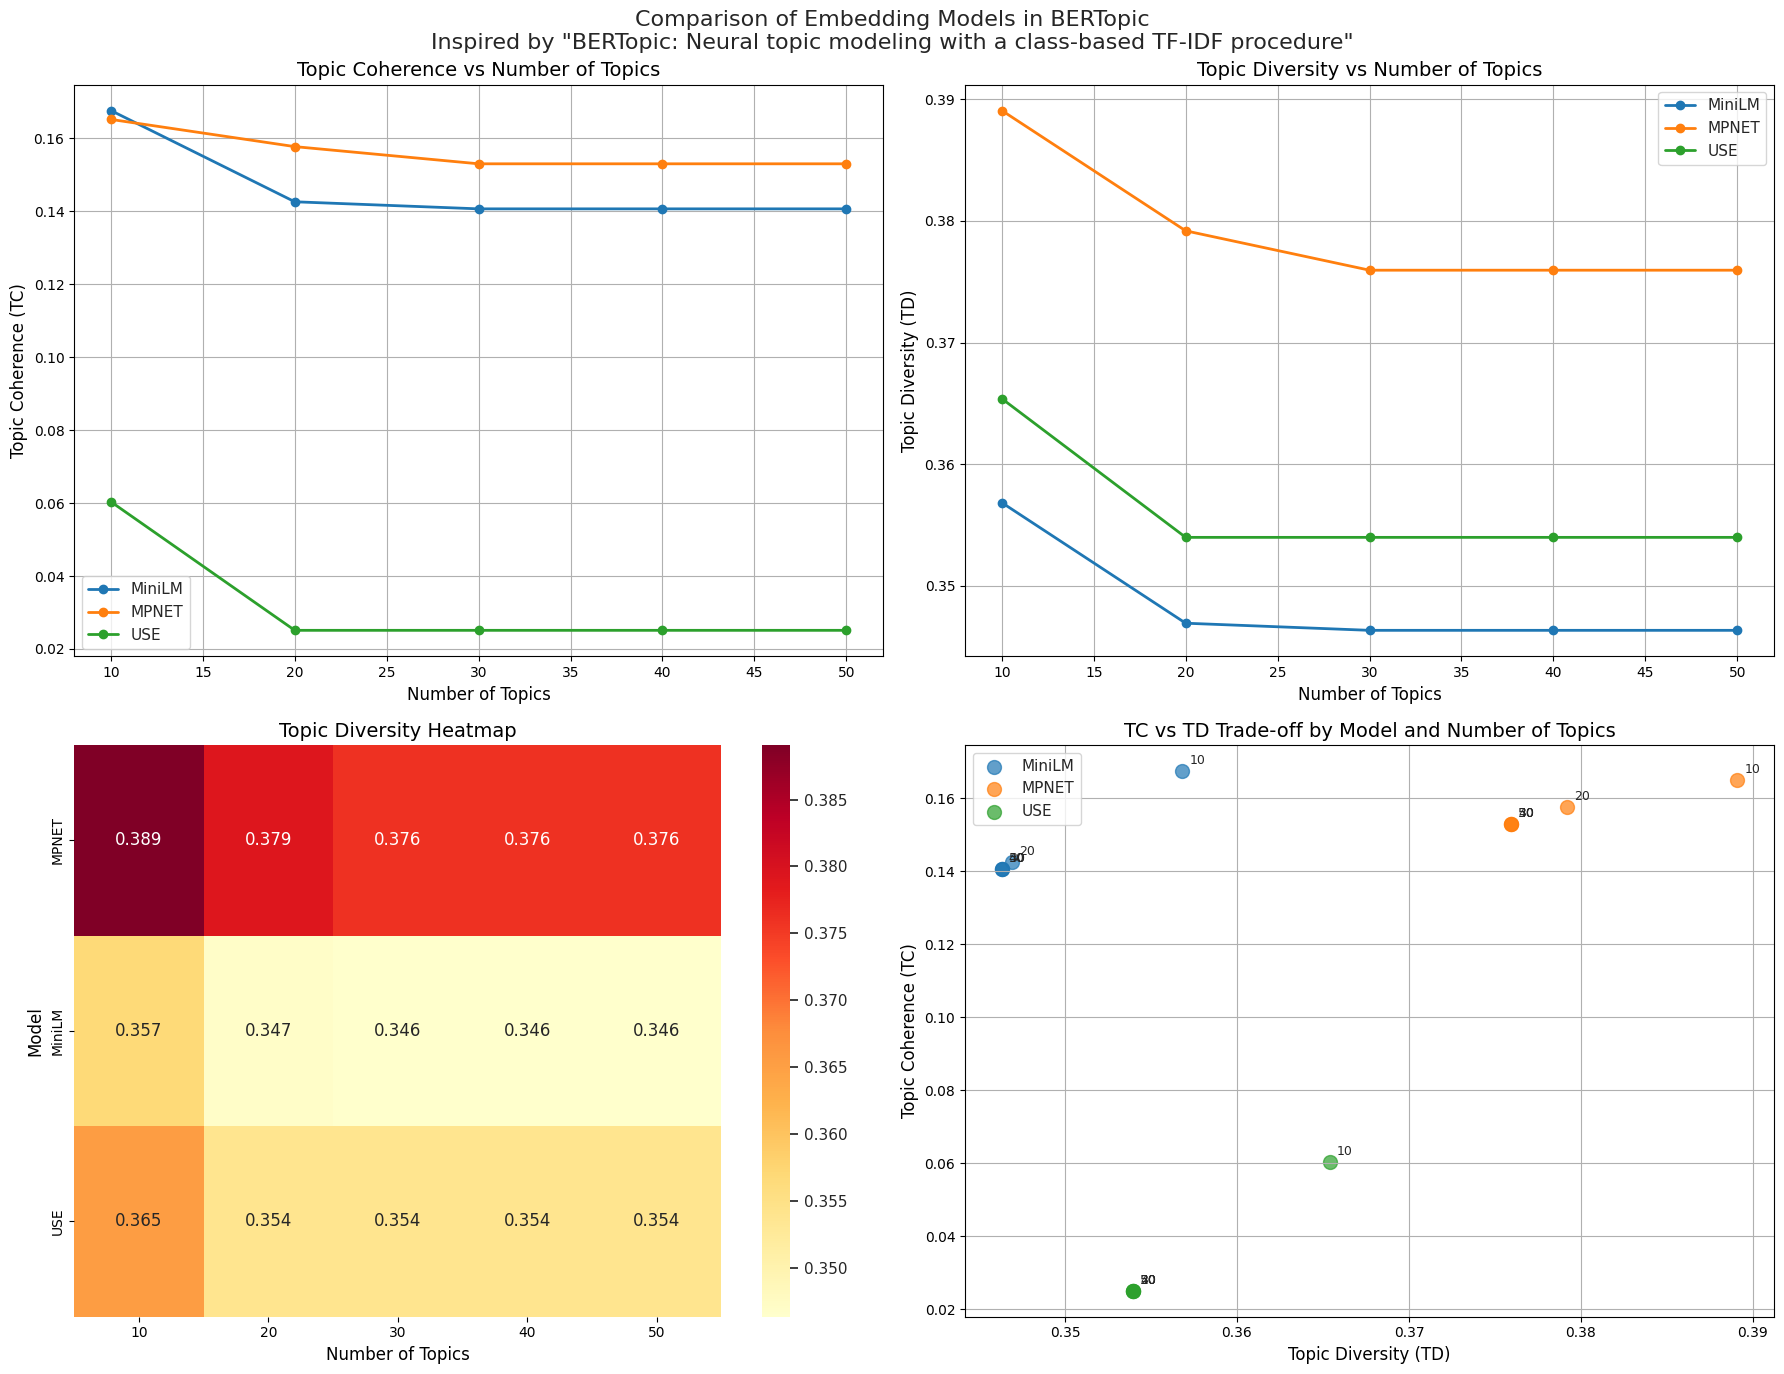

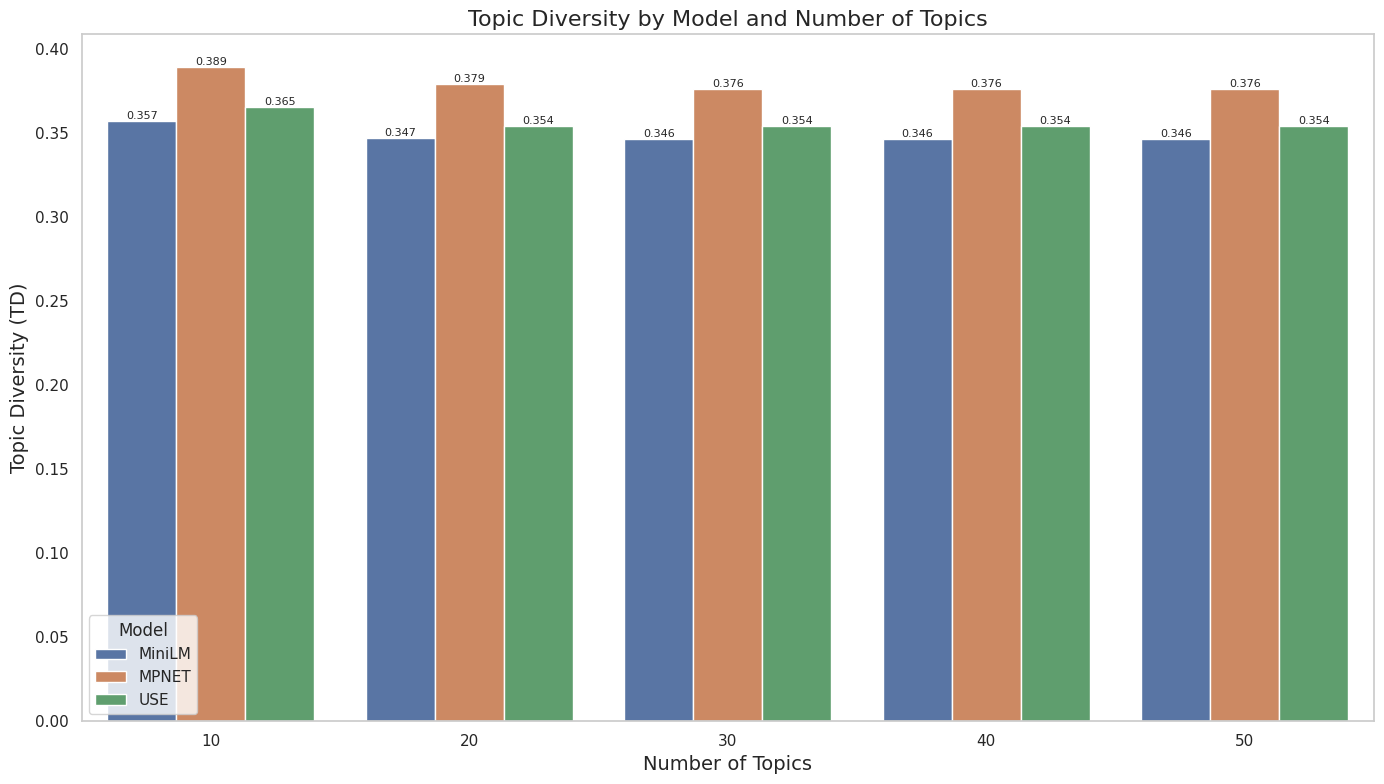

In [26]:
# Create a figure with multiple subplots
fig, axs = plt.subplots(2, 2, figsize=(18, 14))

# Set seaborn style for better aesthetics
sns.set(style="whitegrid")

# 1. Line plots for TC and TD
for model in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model]
    axs[0, 0].plot(model_data['n_topics'], model_data['TC'], marker='o', linewidth=2, label=model)
    axs[0, 1].plot(model_data['n_topics'], model_data['TD'], marker='o', linewidth=2, label=model)

axs[0, 0].set_xlabel('Number of Topics', fontsize=12)
axs[0, 0].set_ylabel('Topic Coherence (TC)', fontsize=12)
axs[0, 0].set_title('Topic Coherence vs Number of Topics', fontsize=14)
axs[0, 0].legend()
axs[0, 0].grid(True)

axs[0, 1].set_xlabel('Number of Topics', fontsize=12)
axs[0, 1].set_ylabel('Topic Diversity (TD)', fontsize=12)
axs[0, 1].set_title('Topic Diversity vs Number of Topics', fontsize=14)
axs[0, 1].legend()
axs[0, 1].grid(True)

# 2. Heatmap for TD
pivot_td = df_results.pivot_table(index='model', columns='n_topics', values='TD')
sns.heatmap(pivot_td, annot=True, cmap='YlOrRd', fmt='.3f', ax=axs[1, 0])
axs[1, 0].set_title('Topic Diversity Heatmap', fontsize=14)
axs[1, 0].set_ylabel('Model', fontsize=12)
axs[1, 0].set_xlabel('Number of Topics', fontsize=12)

# 3. Scatter plot of TC vs TD to visualize trade-offs
for model in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model]
    axs[1, 1].scatter(model_data['TD'], model_data['TC'], label=model, s=100, alpha=0.7)

    # Add annotations for n_topics
    for i, row in model_data.iterrows():
        axs[1, 1].annotate(f"{int(row['n_topics'])}",
                         (row['TD'], row['TC']),
                         xytext=(5, 5),
                         textcoords='offset points',
                         fontsize=9)

axs[1, 1].set_xlabel('Topic Diversity (TD)', fontsize=12)
axs[1, 1].set_ylabel('Topic Coherence (TC)', fontsize=12)
axs[1, 1].set_title('TC vs TD Trade-off by Model and Number of Topics', fontsize=14)
axs[1, 1].legend()
axs[1, 1].grid(True)

# Add a main title referencing the BERTopic paper
fig.suptitle('Comparison of Embedding Models in BERTopic\nInspired by "BERTopic: Neural topic modeling with a class-based TF-IDF procedure"',
             fontsize=16, y=0.98)

plt.tight_layout()
plt.savefig('bertopic_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional visualizations specifically for Topic Diversity

# Bar chart comparing TD across models at different n_topics
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='n_topics', y='TD', hue='model', data=df_results)
plt.title('Topic Diversity by Model and Number of Topics', fontsize=16)
plt.xlabel('Number of Topics', fontsize=14)
plt.ylabel('Topic Diversity (TD)', fontsize=14)
plt.legend(title='Model')
plt.grid(axis='y')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)
plt.tight_layout()
plt.savefig('bertopic_td_comparison.png', dpi=300)
plt.show()